# Week 6 Assessment: Denoising Autoencoder on MNIST


## 1. Imports & GPU check


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import (
    InputLayer,
    Conv2D,
    Conv2DTranspose,
    Reshape,
    Lambda
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.losses import MeanSquaredError
import os

# Check GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 0


## 2. Load the MNIST Dataset


In [2]:
train, test = tf.keras.datasets.mnist.load_data(path="mnist.npz")

train_x, train_y = train
test_x, test_y = test

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)


(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


## 3. Add Random Noise


In [3]:
train_x_noisey = (
    train_x + 15 * tf.random.normal(shape=train_x.shape)
).numpy()

test_x_noisey = (
    test_x + 15 * tf.random.normal(shape=test_x.shape)
).numpy()


## 4. Helper to Plot Images


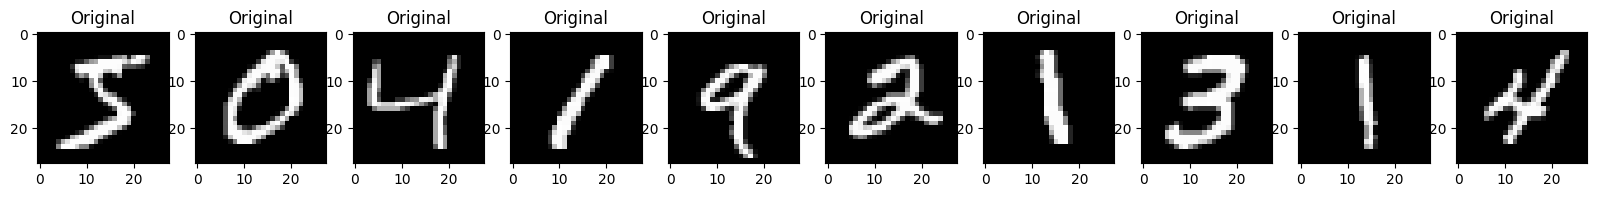

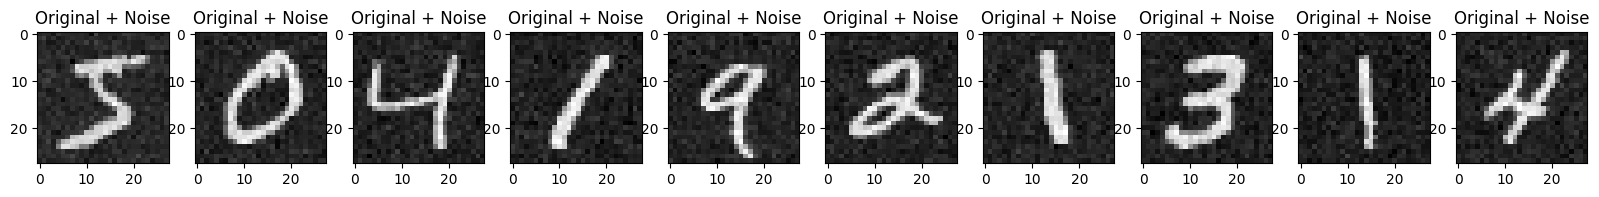

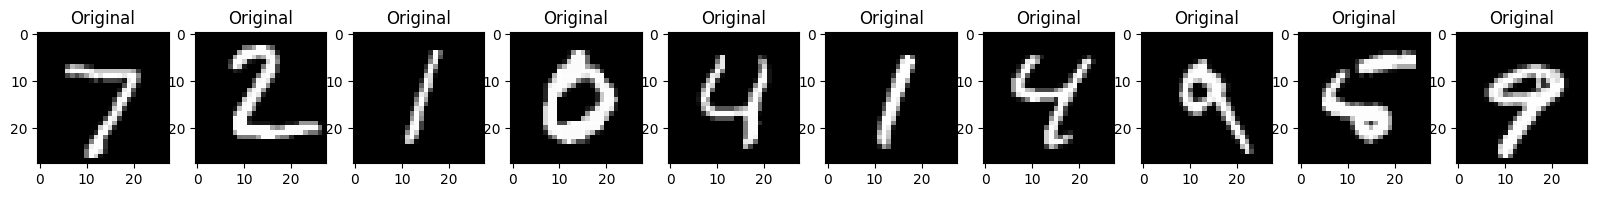

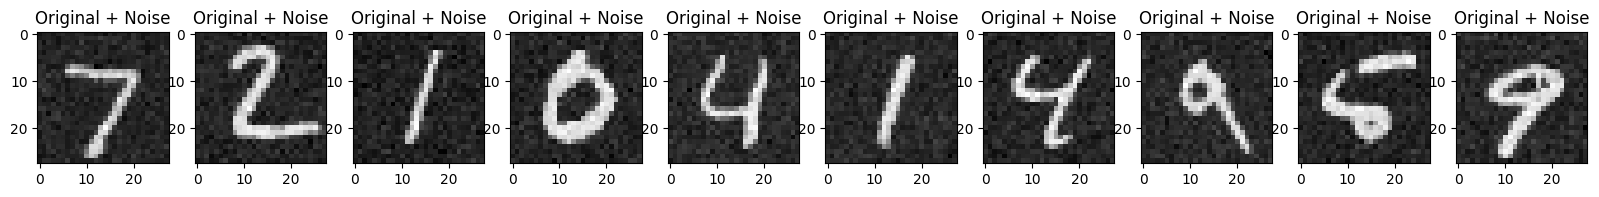

In [4]:
def plot_original_and_noisey(original=train_x,
                             noisey=train_x_noisey,
                             n=10):

    plt.figure(figsize=(20, 2))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.title("Original")
        plt.imshow(tf.squeeze(original[i]))
        plt.gray()

    plt.show()

    plt.figure(figsize=(20, 2))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.title("Original + Noise")
        plt.imshow(tf.squeeze(noisey[i]))
        plt.gray()

    plt.show()

# Display sample train images
plot_original_and_noisey()

# Display sample test images
plot_original_and_noisey(
    original=test_x,
    noisey=test_x_noisey
)


## 5. Split Test Set into Validation and Test


In [5]:
val_x_noisey, test_x_noisey, val_x, test_x = train_test_split(
    test_x_noisey,
    test_x,
    test_size=0.5,
    random_state=42
)

print(val_x.shape)
print(test_x.shape)
print(val_x_noisey.shape)
print(test_x_noisey.shape)


(5000, 28, 28)
(5000, 28, 28)
(5000, 28, 28)
(5000, 28, 28)


## 6. Model Checkpoint




In [6]:
os.makedirs("checkpoints", exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath="checkpoints/ImageDenoiser.keras",
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    mode="min"
)


## 7. Convolutional Denoising Autoencoder


In [7]:
class Denoise(Model):

    def __init__(self):
        super(Denoise, self).__init__()

        # Encoder
        self.encoder = Sequential([
            InputLayer(input_shape=(28, 28)),
            Reshape((28, 28, 1)),
            Lambda(lambda x: x / 255),

            Conv2D(
                16,
                (3, 3),
                activation="relu",
                padding="same",
                strides=2
            ),

            Conv2D(
                8,
                (3, 3),
                activation="relu",
                padding="same",
                strides=2
            )
        ])

        # Decoder
        self.decoder = Sequential([
            Conv2DTranspose(
                8,
                kernel_size=3,
                strides=2,
                activation="relu",
                padding="same"
            ),

            Conv2DTranspose(
                16,
                kernel_size=3,
                strides=2,
                activation="relu",
                padding="same"
            ),

            Conv2D(
                1,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            )
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


## 8. Create and Compile Model


In [8]:
autoencoder = Denoise()


_ = autoencoder(train_x_noisey[:1])

autoencoder.compile(
    optimizer="adam",
    loss=MeanSquaredError()
)


c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


## 9. Train Model


In [9]:
autoencoder.fit(
    train_x_noisey,
    train_x,
    validation_data=(val_x_noisey, val_x),
    epochs=10,
    callbacks=[checkpoint]
)


Epoch 1/10
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 944.2677
Epoch 1: val_loss improved from None to 235.00110, saving model to checkpoints/ImageDenoiser.keras

Epoch 1: finished saving model to checkpoints/ImageDenoiser.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 941.9981 - val_loss: 235.0011
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 198.1742
Epoch 2: val_loss improved from 235.00110 to 168.18820, saving model to checkpoints/ImageDenoiser.keras

Epoch 2: finished saving model to checkpoints/ImageDenoiser.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 198.1742 - val_loss: 168.1882
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 152.2462
Epoch 3: val_loss improved from 168.18820 to 139.13336, saving model to checkpoints/ImageDenoiser.keras

Epoch 3: finished saving model to checkpoints/ImageDenoiser.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 152.2462 - val_loss: 139.1334
Epoch 4/10
1869/1875 ━━━━━━━━━━━━

## 10. Model Summary


In [10]:
autoencoder.summary()

# Encoder Summary
autoencoder.encoder.summary()


Model: "denoise"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 7, 7, 8)        │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (1, 28, 28, 1)         │         1,897 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,653 (37.71 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Denoise Test Images


In [11]:
test_x_denoised = autoencoder(test_x_noisey).numpy()

print(test_x_denoised.shape)

# Remove channel dimension
test_x_denoised = test_x_denoised.reshape(test_x_noisey.shape)

print(test_x_denoised.shape)


(5000, 28, 28, 1)
(5000, 28, 28)


## 12. Plot Results


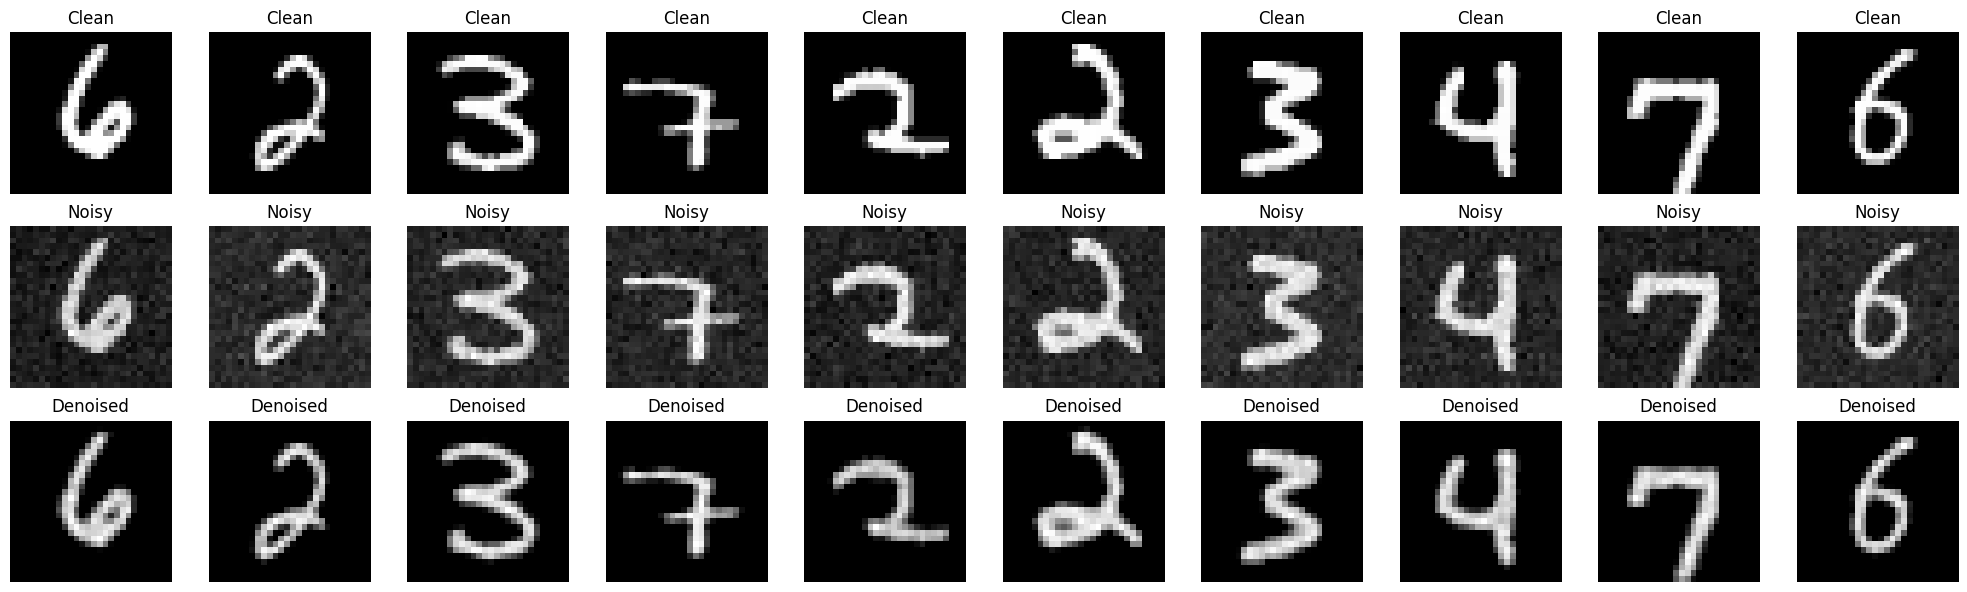

In [12]:
def plot_three_way(clean, noisy, denoised, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(tf.squeeze(clean[i]), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

        plt.subplot(3, n, n + i + 1)
        plt.imshow(tf.squeeze(noisy[i]), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        plt.subplot(3, n, 2*n + i + 1)
        plt.imshow(tf.squeeze(denoised[i]), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_three_way(test_x, test_x_noisey, test_x_denoised)

## 13. Analysis

- **Data preparation**: MNIST digits were loaded, and Gaussian noise (std=15, on the raw 0-255 pixel scale) was added to create noisy inputs. Pixel normalization to `[0,1]` happens inside the model via a `Lambda` layer, so the raw noisy/clean pixel values are used directly for training and evaluation.
- **Architecture**: A convolutional autoencoder — two strided `Conv2D` layers compress the 28x28 image down to a 7x7x8 bottleneck, and two `Conv2DTranspose` layers expand it back to 28x28, with a final `Conv2D` producing the reconstructed image.
- **Training**: Trained for 10 epochs using the Adam optimizer and MSE loss between the noisy input and clean target, with the best-performing weights (by validation loss) checkpointed to disk.
- **Result**: The plotted comparison above shows the noisy test digits alongside their denoised reconstructions. Fill in your own observation here once you've run it, e.g. how well fine strokes/loops are preserved, and whether any digits are harder to denoise than others.
- **Challenges**: The main practical issue encountered was a Keras version mismatch in `ModelCheckpoint`'s filepath requirements (newer Keras requires an explicit `.keras`/`.weights.h5` extension), which was fixed by adjusting the checkpoint filepath.
